In [ ]:
import numpy as np

def softmax(z):
    # Step 1: Prevent numerical overflow (very large numbers)
    # Subtract the maximum value in each row
    z_shifted = z - np.max(z, axis=1, keepdims=True)

    # Step 2: Calculate e^z for each value
    exp_z = np.exp(z_shifted)

    # Step 3: Sum e^z across classes for each sample
    sum_exp_z = np.sum(exp_z, axis=1, keepdims=True)

    # Step 4: Divide to get probabilities
    probabilities = exp_z / sum_exp_z

    return probabilities

In [ ]:
def predict_softmax(X, W, b):
    # Step 1: Calculate raw scores (z = XW + b)
    z = np.dot(X, W) + b

    # Step 2: Convert to probabilities using softmax
    probabilities = softmax(z)

    # Step 3: Pick the class with highest probability
    predicted_classes = np.argmax(probabilities, axis=1)

    return predicted_classes

In [ ]:
def loss_softmax(y_pred, y):
    # Step 1: Avoid log(0) which is -infinity
    # Add tiny number (1e-15) to prevent log(0)
    epsilon = 1e-15
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)

    # Step 2: Calculate cross-entropy loss
    # For a single sample: -sum(y_true * log(y_pred))
    loss = -np.sum(y * np.log(y_pred_clipped))

    return loss

In [ ]:
def cost_softmax(X, y, W, b):
    n = X.shape[0]  # number of samples

    # Step 1: Get raw scores
    z = np.dot(X, W) + b

    # Step 2: Convert to probabilities
    y_pred = softmax(z)

    # Step 3: Calculate loss for each sample and average
    total_loss = 0
    for i in range(n):
        total_loss += loss_softmax(y_pred[i], y[i])

    # Step 4: Return average loss
    return total_loss / n

In [ ]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]  # number of samples

    # Step 1: Forward pass - get predictions
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    # Step 2: Calculate error (prediction - truth)
    error = y_pred - y

    # Step 3: Gradient for weights
    grad_W = np.dot(X.T, error) / n

    # Step 4: Gradient for biases
    grad_b = np.sum(error, axis=0) / n

    return grad_W, grad_b

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        # Step 1: Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Step 2: Update parameters (move downhill)
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Step 3: Track progress
        if show_cost and i % 100 == 0:
            current_cost = cost_softmax(X, y, W, b)
            cost_history.append(current_cost)
            print(f"Iteration {i}: Cost = {current_cost:.6f}")

    return W, b, cost_history

Displaying sample images from the MNIST dataset:


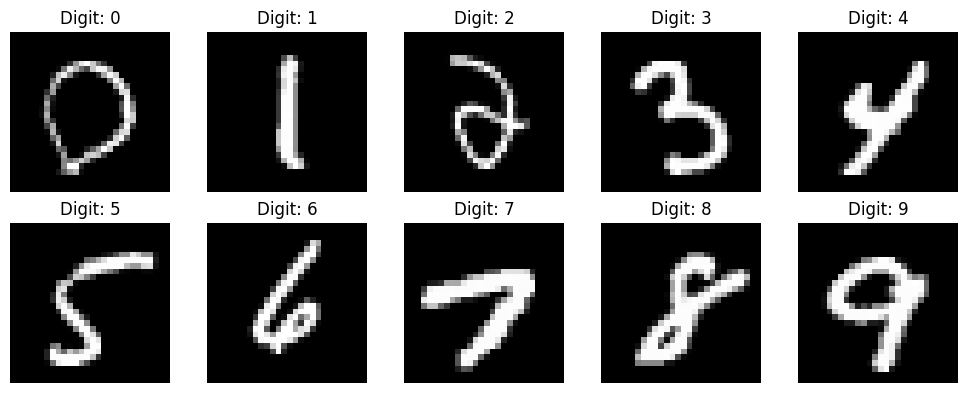

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    # Step 1: Load CSV file
    df = pd.read_csv(csv_file)

    # Step 2: Separate labels (first column) and features (all other columns)
    y = df.iloc[:, 0].values  # First column is the digit label
    X = df.iloc[:, 1:].values  # Rest are pixel values (0-255)

    # Step 3: Normalize pixel values (scale to 0-1 range)
    # This helps the algorithm learn faster
    X = X / 255.0

    # Step 4: Split into training (80%) and testing (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    return X_train, X_test, y_train, y_test

def plot_sample_images(X, y):
    """Display one example of each digit (0-9)"""
    plt.figure(figsize=(10, 4))

    for digit in range(10):
        # Find first occurrence of this digit
        idx = np.where(y == digit)[0][0]
        image = X[idx].reshape(28, 28)  # Reshape to 28x28

        plt.subplot(2, 5, digit + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Code to call the functions and display output ---

# Define the path to the dataset
mnist_csv_path = "/content/sample_data/mnist_train_small.csv"

# Load and prepare the data
X_train, X_test, y_train, y_test = load_and_prepare_mnist(mnist_csv_path)

# Plot sample images from the training set
print("Displaying sample images from the MNIST dataset:")
plot_sample_images(X_train, y_train)

Iteration 0: Cost = 2.189140
Iteration 100: Cost = 0.595946
Iteration 200: Cost = 0.477395
Iteration 300: Cost = 0.427844
Iteration 400: Cost = 0.398945
Iteration 500: Cost = 0.379379
Iteration 600: Cost = 0.364954
Iteration 700: Cost = 0.353717
Iteration 800: Cost = 0.344617
Iteration 900: Cost = 0.337034


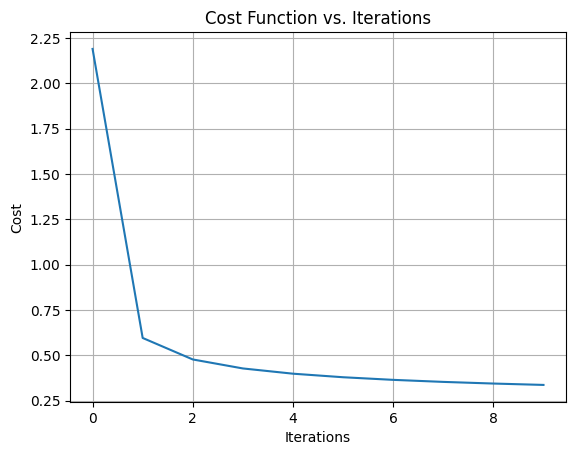

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

def softmax(z):
    # Step 1: Prevent numerical overflow (very large numbers)
    # Subtract the maximum value in each row
    z_shifted = z - np.max(z, axis=1, keepdims=True)

    # Step 2: Calculate e^z for each value
    exp_z = np.exp(z_shifted)

    # Step 3: Sum e^z across classes for each sample
    sum_exp_z = np.sum(exp_z, axis=1, keepdims=True)

    # Step 4: Divide to get probabilities
    probabilities = exp_z / sum_exp_z

    return probabilities

def loss_softmax(y_pred, y):
    # Step 1: Avoid log(0) which is -infinity
    # Add tiny number (1e-15) to prevent log(0)
    epsilon = 1e-15
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)

    # Step 2: Calculate cross-entropy loss
    # For a single sample: -sum(y_true * log(y_pred))
    loss = -np.sum(y * np.log(y_pred_clipped))

    return loss

def cost_softmax(X, y, W, b):
    n = X.shape[0]  # number of samples

    # Step 1: Get raw scores
    z = np.dot(X, W) + b

    # Step 2: Convert to probabilities
    y_pred = softmax(z)

    # Step 3: Calculate loss for each sample and average
    total_loss = 0
    for i in range(n):
        total_loss += loss_softmax(y_pred[i], y[i])

    # Step 4: Return average loss
    return total_loss / n

def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]  # number of samples

    # Step 1: Forward pass - get predictions
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    # Step 2: Calculate error (prediction - truth)
    error = y_pred - y

    # Step 3: Gradient for weights
    grad_W = np.dot(X.T, error) / n

    # Step 4: Gradient for biases
    grad_b = np.sum(error, axis=0) / n

    return grad_W, grad_b

def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        # Step 1: Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Step 2: Update parameters (move downhill)
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Step 3: Track progress
        if show_cost and i % 100 == 0:
            current_cost = cost_softmax(X, y, W, b)
            cost_history.append(current_cost)
            print(f"Iteration {i}: Cost = {current_cost:.6f}")

    return W, b, cost_history

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

# Initialize parameters
d = X_train.shape[1]  # 784 features
c = 10  # 10 classes
W = np.random.randn(d, c) * 0.01  # Small random weights
b = np.zeros(c)  # Zero biases

# Train
alpha = 0.1  # Learning rate
n_iter = 1000  # Iterations
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train_encoded, W, b, alpha, n_iter, show_cost=True
)

# Plot learning curve
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

Precision: 0.90
Recall: 0.90
F1-Score: 0.90


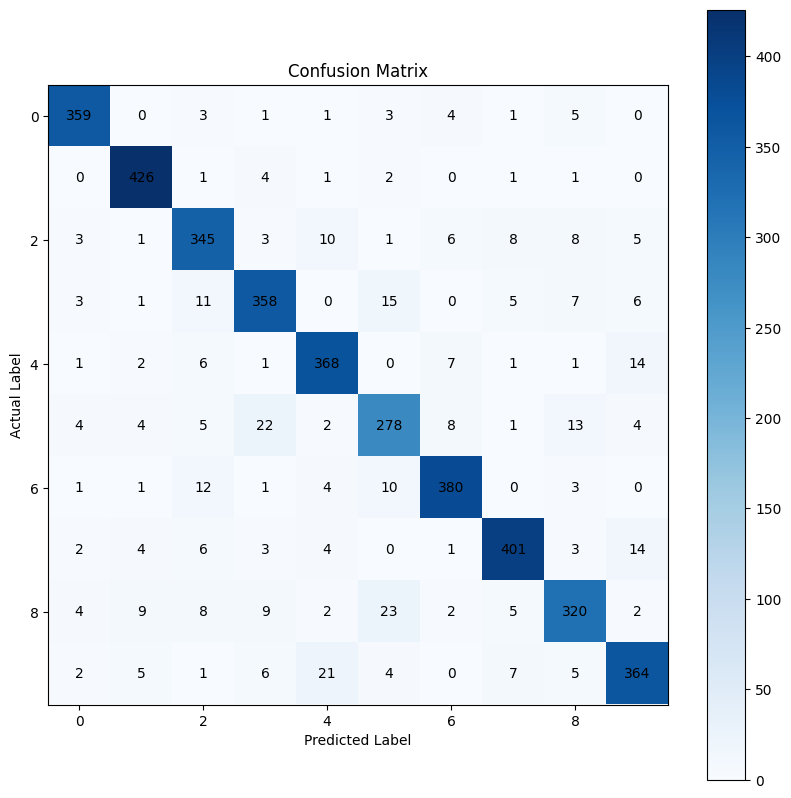

In [8]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np # Import numpy as it's used by softmax and predict_softmax
import matplotlib.pyplot as plt # Import matplotlib for plotting confusion matrix

def softmax(z):
    # Step 1: Prevent numerical overflow (very large numbers)
    # Subtract the maximum value in each row
    z_shifted = z - np.max(z, axis=1, keepdims=True)

    # Step 2: Calculate e^z for each value
    exp_z = np.exp(z_shifted)

    # Step 3: Sum e^z across classes for each sample
    sum_exp_z = np.sum(exp_z, axis=1, keepdims=True)

    # Step 4: Divide to get probabilities
    probabilities = exp_z / sum_exp_z

    return probabilities

def predict_softmax(X, W, b):
    # Step 1: Calculate raw scores (z = XW + b)
    z = np.dot(X, W) + b

    # Step 2: Convert to probabilities using softmax
    probabilities = softmax(z)

    # Step 3: Pick the class with highest probability
    predicted_classes = np.argmax(probabilities, axis=1)

    return predicted_classes

def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

# Make predictions
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# Get true labels (convert from one-hot)
y_test_labels = np.argmax(y_test_encoded, axis=1)

# Evaluate
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Plot confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Add numbers to cells
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.show()

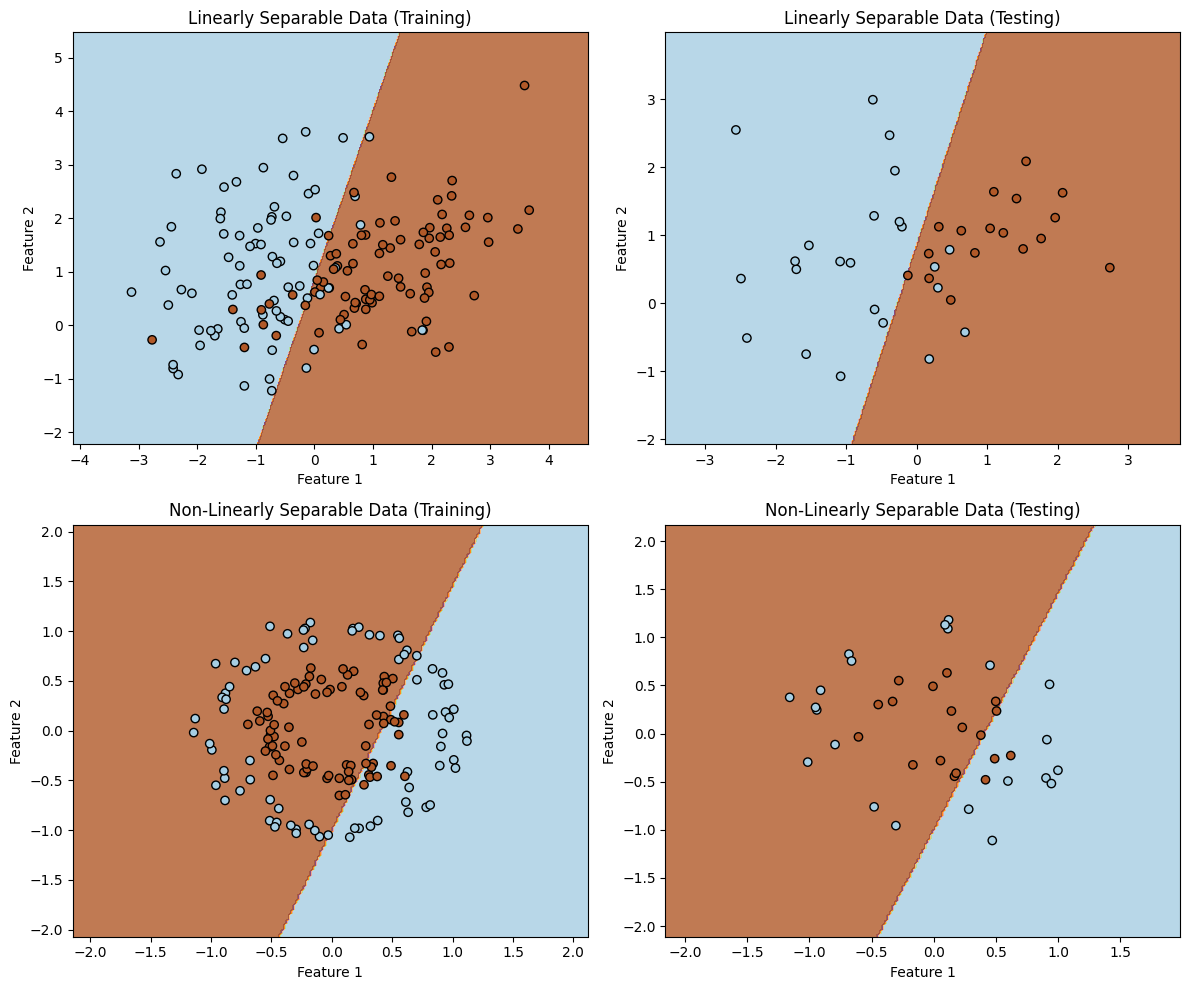

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Set random seed for reproducibility
np.random.seed(42)

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(n_samples=200, n_features=2,
n_informative=2,
n_redundant=0, n_clusters_per_class=1,
random_state=42)

# Split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(n_samples=200, noise=0.1, factor=0.5,
random_state=42)

# Split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# Plot decision boundaries for linearly and non-linearly separable data
def plot_decision_boundary(ax, model, X, y, title):
    h = .02 # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot decision boundary for linearly separable data (Training)
plot_decision_boundary(axes[0, 0], logistic_model_linear_separable, X_train_linear, y_train_linear,
'Linearly Separable Data (Training)')

# Plot decision boundary for linearly separable data (Testing)
plot_decision_boundary(axes[0, 1], logistic_model_linear_separable, X_test_linear, y_test_linear,
'Linearly Separable Data (Testing)')

# Plot decision boundary for non-linearly separable data (Training)
plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable, X_train_non_linear,
y_train_non_linear, 'Non-Linearly Separable Data (Training)')

# Plot decision boundary for non-linearly separable data (Testing)
plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable, X_test_non_linear,
y_test_non_linear, 'Non-Linearly Separable Data (Testing)')

plt.tight_layout()

# Save the plots as PNG files
plt.savefig('decision_boundaries.png')
plt.show()